# PSO for Perceptual Image Denoising
Given noisy image $v$, find $\hat{u}$ minimising:
$$\mathcal{L}_p(\hat{u}_p) = 1 - \text{SSIM}(\hat{u}_p, v_p) + \lambda \cdot \text{TV}(\hat{u}_p), \quad \hat{u}_k \in [0,1]$$
Strategy: split into patches, optimise each independently in parallel, stitch back.

In [1]:
# libraries
import numpy as np
import matplotlib.pyplot as plt
import random
from skimage.metrics import structural_similarity as ssim
from skimage import util
from PIL import Image
import pyswarms
import time
import multiprocess as multiprocessing

In [2]:
# parameters
patch_shape = (16, 16)

n_particles = 20
n_iter = 200
init_noise = 0.1

tv_lambda = 0.1
w_inertia = 0.7
c1_cognitive = 1.5
c2_social = 1.5

### 1 – Preprocessing

In [35]:
# load, convert to grayscale, normalize to [0, 1]
with Image.open("slice_noisy.png") as im:
    im_grey = im.convert("L")
print(f"Image format, size, color mode: {im_grey.format, im_grey.size, im_grey.mode}")
im_n = np.array(im_grey) / 255

# pad height to nearest multiple of patch_shape if needed
h, w = im_n.shape
h_pad = int(np.ceil(h / patch_shape[0])) * patch_shape[0]
w_pad = int(np.ceil(w / patch_shape[1])) * patch_shape[1]
pad_h = h_pad - h
pad_w = w_pad - w

if pad_h > 0 or pad_w > 0:
    im_n = np.pad(im_n, ((0, pad_h), (0, pad_w)), mode="reflect")
    print(f"Padded from ({h}, {w}) → {im_n.shape}")
else:
    print(f"Image shape: {im_n.shape} — no padding needed")

Image format, size, color mode: (None, (301, 512), 'L')
Padded from (512, 301) → (512, 304)


Shape of patched image: (32, 19, 16, 16)
Patch shape: (16, 16)


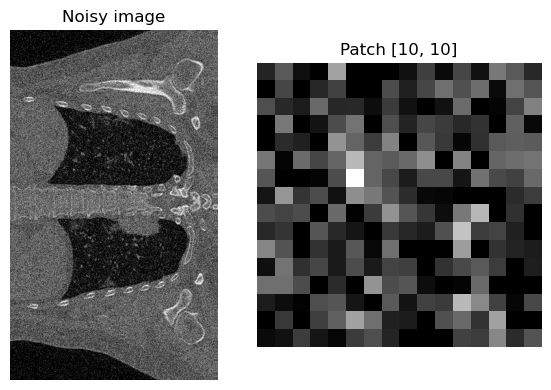

In [39]:
# divide image into patches
patches_im_n = util.view_as_blocks(im_n, patch_shape)
print(f"Shape of patched image: {patches_im_n.shape}")

# select a patch for workflow development
v_patch = patches_im_n[10, 10]
print(f"Patch shape: {v_patch.shape}")

# visualize image and selected patch
fig, axes = plt.subplots(1, 2, figsize=(6, 4))
axes[0].imshow(im_n, cmap="gray")
axes[0].set_title("Noisy image")
axes[0].axis("off")

axes[1].imshow(v_patch, cmap="gray")
axes[1].set_title("Patch [10, 10]")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### 1.2 – Total variation (TV) and objective function
$$\text{TV}(\hat{u}) = \sum_{i,j} \sqrt{(\hat{u}_{i+1,j} - \hat{u}_{i,j})^2 + (\hat{u}_{i,j+1} - \hat{u}_{i,j})^2}$$
Given noisy image $v$, find $\hat{u}$ minimising:
$$\mathcal{L}_p(\hat{u}_p) = 1 - \text{SSIM}(\hat{u}_p, v_p) + \lambda \cdot \text{TV}(\hat{u}_p), \quad \hat{u}_k \in [0,1]$$

In [6]:
# compute difference between each pixel and its right resp. bottom neighbour, drop last column resp. row to address shape differences, then compute TV
def tv(u_patch):
    diff_down = u_patch[1:, :-1] - u_patch[:-1, :-1]
    diff_right = u_patch[:-1, 1:] - u_patch[:-1, :-1]
    return np.sum(np.sqrt(diff_down**2 + diff_right**2))

def objective(u_patch, v_patch):
    ssim_patch = ssim(u_patch, v_patch, data_range = 1.0, full=False, gradient=False)
    return 1.0 - float(ssim_patch) + tv_lambda*tv(u_patch)

In [7]:
# check (0-0 + 0.1 x 46.1)
tv(v_patch)
objective(v_patch, v_patch)

np.float64(3.2883497296901556)

### 2 — PSO (manual)
$$v_i^{t+1} = w \cdot v_i^t + c_1 r_1 (p_i - x_i^t) + c_2 r_2 (g - x_i^t)$$
$$x_i^{t+1} = x_i^t + v_i^{t+1}$$

  - One particle = one candidate denoised patch, flattened to 256 pixel values (one 
  row of x)                                                                         
  - Position of a particle = those 256 pixel values, each in [0,1]                  
  - Velocity of a particle = how much each pixel value changes per iteration — a    
  direction and speed in the 256-dim space                                          
  - Personal best p[i] = the best (lowest loss) position particle i has ever visited
  - Global best g = the best position any particle has ever visited across the whole
   swarm 

In [8]:
#   # initialize swarm: positions, velocities, losses, personal bests, global best                     
v_patch_flat = v_patch.flatten()

# u_particles = np.random.uniform(size = (n_particles, v_patch_flat.size))
# initialize particles near the noisy patch with small perturbations for better convergence

u_particles = v_patch_flat + np.random.uniform(-init_noise, init_noise, size=(n_particles, v_patch_flat.size))   
u_particles = np.clip(u_particles, 0, 1)

u_velocity = np.random.uniform(-0.1, 0.1, size = (n_particles, v_patch_flat.size))

u_patches = u_particles.reshape(n_particles, *patch_shape)
scores = np.array([objective(u_patch, v_patch) for u_patch in u_patches], dtype = float)

u_best_p = u_particles.copy()
u_best_scores = scores.copy()
g_best_p = u_best_p[np.argmin(u_best_scores)]
g_best_scores = np.min(u_best_scores)

#### Particle swarm optimization loop

  Each iteration, for particle i:
  1. Update velocity using w, c1, c2, p[i], g
  2. Update position
  3. Compute new loss → new_score
  4. If new_score < p_scores[i]: update p[i] = new position, p_scores[i] = new_score
  5. If new_score < g_score: update g = new position, g_score = new_score

$$v_i^{t+1} = w \cdot v_i^t + c_1 r_1 (p_i - x_i^t) + c_2 r_2 (g - x_i^t)$$
$$x_i^{t+1} = x_i^t + v_i^{t+1}$$

In [9]:
# no random seed, as PSO stochastic by design, but added for debugging TODO remove random seed
# clamp velocity to [-0.1, 0.1] to prevent particles overshooting the [0,1] pixel range
# clip positions to [0, 1] pixel range

#np.random.seed(42)
convergence = []
t_start = time.time()

for n in range(0, n_iter):
    r1 = np.random.uniform(size = (n_particles, v_patch_flat.size))
    r2 = np.random.uniform(size = (n_particles, v_patch_flat.size))

    u_velocity = w_inertia*u_velocity + c1_cognitive*r1*(u_best_p - u_particles) + c2_social*r2*(g_best_p - u_particles)
    u_velocity = np.clip(u_velocity, -0.1, 0.1)

    u_particles = u_particles + u_velocity
    u_particles = np.clip(u_particles, 0, 1)

    u_patches = u_particles.reshape(n_particles, *patch_shape)
    new_scores = np.array([objective(u_patch, v_patch) for u_patch in u_patches], dtype = float)

    improved = new_scores < u_best_scores
    u_best_scores[improved] = new_scores[improved]
    u_best_p[improved] = u_particles[improved]

    if new_scores.min() < g_best_scores:
        g_best_scores = new_scores.min()
        g_best_p = u_best_p[np.argmin(new_scores)]
    
    convergence.append(g_best_scores)

t_end = time.time()
print(f"Runtime: {t_end - t_start:.2f} s")

Runtime: 0.23 s


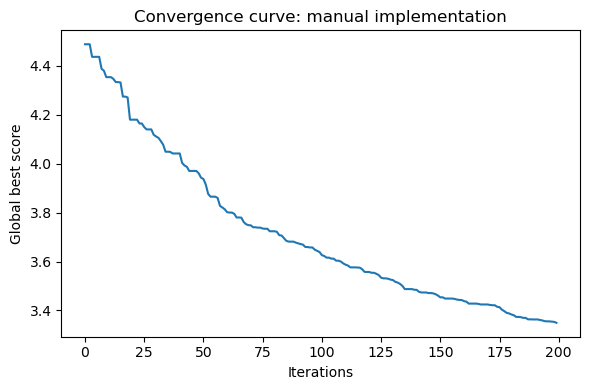

In [9]:
# plot convergence curve
plt.figure(figsize= (6, 4))
plt.plot(convergence)
plt.title("Convergence curve: manual implementation")
plt.xlabel("Iterations")
plt.ylabel("Global best score")
plt.tight_layout()
plt.show()

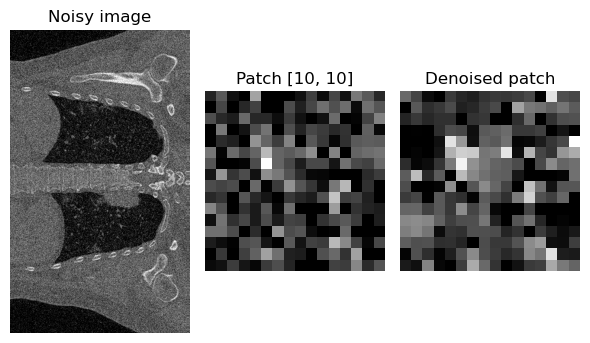

In [10]:
# reshape to 2D:
g_best_p_2d = g_best_p.reshape(patch_shape)

# visualize 
fig, axes = plt.subplots(1, 3, figsize=(6, 4))
axes[0].imshow(im_n, cmap="gray")
axes[0].set_title("Noisy image")
axes[0].axis("off")

axes[1].imshow(v_patch, cmap="gray")
axes[1].set_title("Patch [10, 10]")
axes[1].axis("off")

axes[2].imshow(g_best_p_2d, cmap="gray")
axes[2].set_title("Denoised patch")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### 3 — PSO: pyswarms
Same patch, same hyperparameters.

In [11]:
def wrapper(swarm):
    loss_psw = []
    for s in range(len(swarm)):
        u_part_psw = swarm[s].reshape(patch_shape)
        loss_psw.append(objective(u_part_psw, v_patch))
    return np.array(loss_psw)


In [18]:
min_bound = np.zeros(v_patch_flat.size)
max_bound = np.ones(v_patch_flat.size)
bounds = (min_bound, max_bound)
init_pos = v_patch.flatten() + np.random.uniform(-init_noise, init_noise, size=(n_particles, v_patch.flatten().size))        
init_pos = np.clip(init_pos, 0, 1)

swarm_options = {"c1": c1_cognitive, "c2": c2_social, "w": w_inertia}
optimizer = pyswarms.single.GlobalBestPSO(n_particles, dimensions=v_patch_flat.size, options = swarm_options, velocity_clamp=(-0.1, 0.1), bounds=bounds, init_pos=init_pos)

g_best_scores_psw, g_best_p_psw = optimizer.optimize(wrapper, iters = n_iter)


2026-03-30 21:02:08,170 - pyswarms.single.global_best - INFO - Optimize for 200 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.7}
pyswarms.single.global_best: 100%|██████████|200/200, best_cost=3.42
2026-03-30 21:02:08,522 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 3.4213757968492087, best pos: [0.09752644 0.10013536 0.08822299 0.06522354 0.2876545  0.08314007
 0.0550632  0.0991928  0.06727115 0.13778634 0.28776103 0.03650098
 0.09804523 0.2633665  0.17092253 0.07657478 0.05973755 0.73591864
 0.04752561 0.11818579 0.11058519 0.04344038 0.03176608 0.08885183
 0.09577155 0.15951988 0.17086014 0.1624093  0.22150218 0.30840685
 0.21599616 0.13809283 0.21389621 0.16954264 0.12859543 0.20000692
 0.1698869  0.11823944 0.11593941 0.03955471 0.11633882 0.08317704
 0.03231664 0.22192888 0.09038461 0.19054629 0.17069416 0.2711084
 0.04734148 0.15459045 0.09900283 0.12959312 0.11328763 0.15197392
 0.15116669 0.23079562 0.11875784 0.21820458 0.12134217 0.152985
 0.02436078 

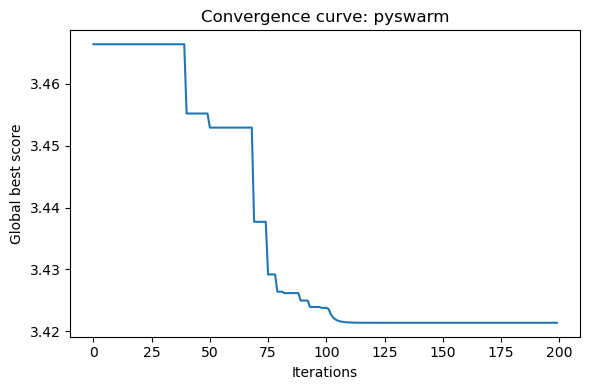

In [19]:
plt.figure(figsize= (6, 4))
plt.plot(optimizer.cost_history)
plt.title("Convergence curve: pyswarm")
plt.xlabel("Iterations")
plt.ylabel("Global best score")
plt.tight_layout()
plt.show()

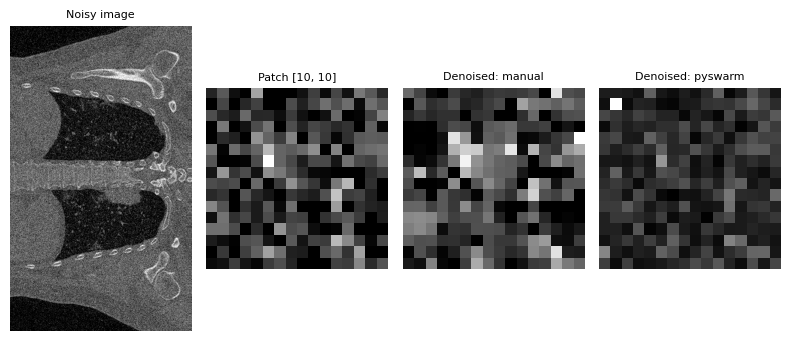

In [20]:
g_best_p_psw_2d = g_best_p_psw.reshape(patch_shape)

# visualize 
fig, axes = plt.subplots(1, 4, figsize=(8, 4))
axes[0].imshow(im_n, cmap="gray")
axes[0].set_title("Noisy image", fontsize=8)
axes[0].axis("off")

axes[1].imshow(v_patch, cmap="gray")
axes[1].set_title("Patch [10, 10]", fontsize=8)
axes[1].axis("off")

axes[2].imshow(g_best_p_2d, cmap="gray")
axes[2].set_title("Denoised: manual", fontsize=8)
axes[2].axis("off")

axes[3].imshow(g_best_p_psw_2d, cmap="gray")
axes[3].set_title("Denoised: pyswarm", fontsize=8)
axes[3].axis("off")

plt.tight_layout()
plt.show()

In [21]:
print(f"Best global score (manual): {g_best_scores:.2f}, Best global score (pyswarm): {g_best_scores_psw:.2f}")

Best global score (manual): 2.26, Best global score (pyswarm): 3.42


### 4 — Full Image Pipeline

#### 4.1 – Manual implementation

In [22]:
def initialize_swarm(v_patch):
    v_patch_flat = v_patch.flatten()
    u_particles = v_patch_flat + np.random.uniform(-init_noise, init_noise, size=(n_particles, v_patch_flat.size))   
    u_particles = np.clip(u_particles, 0, 1)
    u_velocity = np.random.uniform(-0.1, 0.1, size = (n_particles, v_patch_flat.size))

    u_patches = u_particles.reshape(n_particles, *patch_shape)
    scores = np.array([objective(u_patch, v_patch) for u_patch in u_patches], dtype = float)

    u_best_p = u_particles.copy()
    u_best_scores = scores.copy()
    g_best_p = u_best_p[np.argmin(u_best_scores)]
    g_best_scores = np.min(u_best_scores)

    return u_particles, u_velocity, u_best_p, u_best_scores, g_best_p, g_best_scores


In [23]:
def pso_loop(v_patch, u_particles, u_velocity, u_best_p, u_best_scores, g_best_p, g_best_scores):
    for n in range(0, n_iter):
        r1 = np.random.uniform(size = (n_particles, v_patch.flatten().size))
        r2 = np.random.uniform(size = (n_particles, v_patch.flatten().size))

        u_velocity = w_inertia*u_velocity + c1_cognitive*r1*(u_best_p - u_particles) + c2_social*r2*(g_best_p - u_particles)
        u_velocity = np.clip(u_velocity, -0.1, 0.1)

        u_particles = u_particles + u_velocity
        u_particles = np.clip(u_particles, 0, 1)

        u_patches = u_particles.reshape(n_particles, *patch_shape)
        new_scores = np.array([objective(u_patch, v_patch) for u_patch in u_patches], dtype = float)

        improved = new_scores < u_best_scores
        u_best_scores[improved] = new_scores[improved]
        u_best_p[improved] = u_particles[improved]

        if new_scores.min() < g_best_scores:
            g_best_scores = new_scores.min()
            g_best_p = u_best_p[np.argmin(new_scores)]
        
    return g_best_scores, g_best_p

In [24]:
def denoise_patch_manual(v_patch):
    u_particles, u_velocity, u_best_p, u_best_scores, g_best_p, g_best_scores = initialize_swarm(v_patch)
    g_best_scores, g_best_p = pso_loop(v_patch, u_particles, u_velocity, u_best_p, u_best_scores, g_best_p, g_best_scores)
    return g_best_p.reshape(patch_shape)

In [25]:
# batch process image patches
# here: stitch patches back: list → (1024, 16, 16) → (32, 32, 16, 16) →                                  
# transpose to (32, 16, 32, 16) so pixels of the same image row are adjacent → (512, 512)

def denoise_image_manual(im_n):
    patches_im_n = util.view_as_blocks(im_n, patch_shape)
    v_patches = patches_im_n.reshape(-1, *patch_shape)
    
    with multiprocessing.Pool() as pool:
        denoised_patches = pool.map(denoise_patch_manual, v_patches)
    
    denoised_patches_arr = np.array(denoised_patches)
    n_rows = im_n.shape[0] // patch_shape[0]                                                       
    n_cols = im_n.shape[1] // patch_shape[1] 
    den_reshaped = denoised_patches_arr.reshape(n_rows, n_cols, patch_shape[0], patch_shape[1])
    den_final = den_reshaped.transpose(0, 2, 1, 3).reshape(im_n.shape)
    return den_final

In [26]:
denoised_im = denoise_image_manual(im_n)

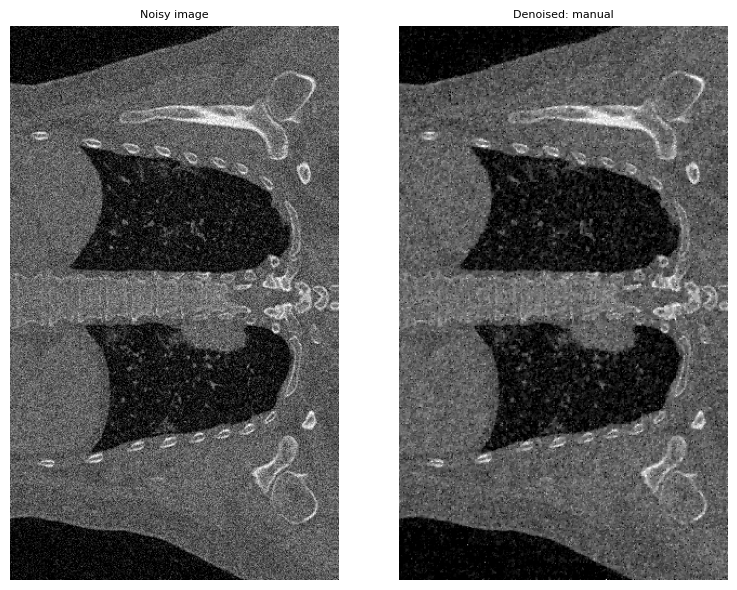

In [29]:
# visualize 
fig, axes = plt.subplots(1, 2, figsize=(8, 6))
axes[0].imshow(im_n, cmap="gray")
axes[0].set_title("Noisy image", fontsize=8)
axes[0].axis("off")

axes[1].imshow(denoised_im, cmap="gray")
axes[1].set_title("Denoised: manual", fontsize=8)
axes[1].axis("off")

plt.tight_layout()
plt.show()

#### 4.2 – pyswarm implementation

In [30]:
def denoise_patch_pyswarms(v_patch):
  v_patch_flat = v_patch.flatten()
  init_pos = v_patch_flat + np.random.uniform(-init_noise, init_noise, size=(n_particles, v_patch_flat.size))
  init_pos = np.clip(init_pos, 0, 1)
  
  def wrapper(swarm):
    return np.array([objective(swarm[s].reshape(patch_shape), v_patch) for s in range(len(swarm))])
    
  bounds = (np.zeros(v_patch_flat.size), np.ones(v_patch_flat.size))
  swarm_options = {"c1": c1_cognitive, "c2": c2_social, "w": w_inertia}
  optimizer = pyswarms.single.GlobalBestPSO(n_particles, dimensions=v_patch_flat.size, options=swarm_options, bounds=bounds, velocity_clamp=(-0.1, 0.1), init_pos=init_pos)
  best_cost, best_pos = optimizer.optimize(wrapper, iters=n_iter, verbose=False)
  
  return best_pos.reshape(patch_shape)


In [32]:
def denoise_image_pyswarms(im_n):
    patches_im_n = util.view_as_blocks(im_n, patch_shape)
    v_patches = patches_im_n.reshape(-1, *patch_shape)
    
    with multiprocessing.Pool() as pool:
       denoised_patches = pool.map(denoise_patch_pyswarms, v_patches)
       
    denoised_patches_arr = np.array(denoised_patches)
    n_rows = im_n.shape[0] // patch_shape[0]
    n_cols = im_n.shape[1] // patch_shape[1]
    den_reshaped = denoised_patches_arr.reshape(n_rows, n_cols, patch_shape[0], patch_shape[1])
    den_final = den_reshaped.transpose(0, 2, 1, 3).reshape(im_n.shape)
    return den_final

In [33]:
denoised_im_psw = denoise_image_pyswarms(im_n)

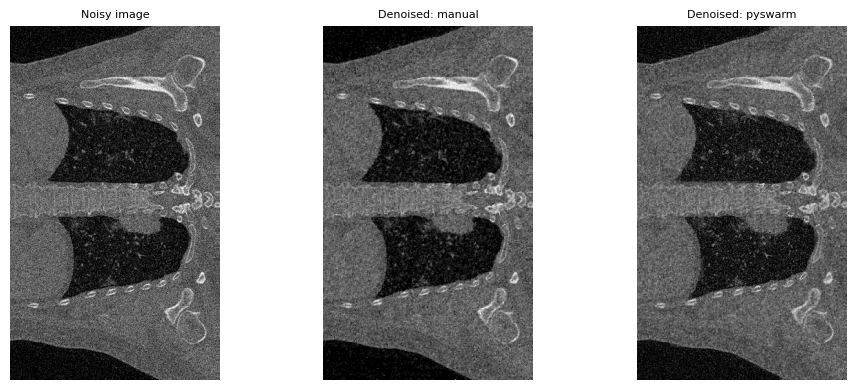

In [34]:
# visualize 
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
axes[0].imshow(im_n, cmap="gray")
axes[0].set_title("Noisy image", fontsize=8)
axes[0].axis("off")

axes[1].imshow(denoised_im, cmap="gray")
axes[1].set_title("Denoised: manual", fontsize=8)
axes[1].axis("off")

axes[2].imshow(denoised_im_psw, cmap="gray")
axes[2].set_title("Denoised: pyswarm", fontsize=8)
axes[2].axis("off")

plt.tight_layout()
plt.show()